In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import scipy.optimize as sco
import time
import pandas_datareader.data as web
import warnings
import statsmodels.api as sm
import seaborn as sns
warnings.filterwarnings('ignore')

In [79]:
# Define the stocks
tech_stocks = ['AAPL', 'MSFT', 'GOOGL', 'TSM', 'META']
financial_stocks = ['JPM', 'BAC', 'GS', 'MS', 'V']
stocks = tech_stocks + financial_stocks
market_index = ['^GSPC']  # S&P 500

# Date range
start_date = datetime(2017, 12, 29)  # Last trading day of 2017
end_date = datetime(2018, 12, 31)

def download_stock_data(tickers, start_date, end_date, source='stooq'):
    """
    Download stock data with robust error handling.
    Using 'stooq' as an alternative data source that's less likely to rate-limit.
    """
    all_data = {}
    
    for ticker in tickers:
        print(f"Downloading {ticker}...")
        
        # Map Yahoo Finance symbols to stooq format if needed
        ticker_mapped = ticker
        if ticker == '^GSPC' and source == 'stooq':
            ticker_mapped = '^SPX'  # stooq format for S&P 500
            
        max_attempts = 5
        for attempt in range(max_attempts):
            try:
                df = web.DataReader(ticker_mapped, source, start_date, end_date)
                
                # Some sources return columns in different formats
                if 'Adj Close' in df.columns:
                    all_data[ticker] = df['Adj Close']
                elif 'Close' in df.columns:
                    all_data[ticker] = df['Close']
                else:
                    # Try getting the first numeric column
                    for col in df.columns:
                        if np.issubdtype(df[col].dtype, np.number):
                            all_data[ticker] = df[col]
                            break
                
                print(f"Successfully downloaded {ticker}")
                time.sleep(1)  # Small delay between successful downloads
                break
                
            except Exception as e:
                print(f"Attempt {attempt+1}/{max_attempts} for {ticker} failed: {e}")
                delay = 5 * (attempt + 1)  # Increasing delay with each attempt
                print(f"Waiting {delay} seconds before retry...")
                time.sleep(delay)
                
        if ticker not in all_data:
            print(f"Failed to download {ticker} after {max_attempts} attempts")
            
    # Combine all data into a single DataFrame
    if all_data:
        result = pd.DataFrame(all_data)
        result.sort_index(inplace=True)
        return result
    else:
        return pd.DataFrame()

# Try to get Treasury data from FRED (more reliable than Yahoo for rates)
def get_treasury_data(start_date, end_date):
    try:
        print("Downloading Treasury data from FRED...")
        # DTB3 is the 3-month Treasury bill rate
        treasury_data = web.DataReader('DTB3', 'fred', start_date, end_date)
        print("Successfully downloaded Treasury data")
        return treasury_data
    except Exception as e:
        print(f"Failed to download Treasury data: {e}")
        # Create a simple interpolated series as fallback
        dates = pd.date_range(start=start_date, end=end_date, freq='B')
        rates = np.linspace(1.5, 2.5, len(dates))  # Typical range for 3-month T-bills in 2018
        return pd.DataFrame(rates, index=dates, columns=['DTB3'])

# Download data
print("Downloading stock data...")
stock_data = download_stock_data(stocks + market_index, start_date, end_date)
print("Stock data shape:", stock_data.shape)

print("Downloading treasury data...")
treasury_data = get_treasury_data(start_date, end_date)
print("Treasury data shape:", treasury_data.shape)

# Process the downloaded data
# Calculate daily returns
returns = stock_data.pct_change().dropna()

# Convert treasury rates to daily (annualized rates in percentage)
daily_rf_rate = treasury_data / 100 / 252  # Simple conversion for daily rate

# Create a DataFrame with daily risk-free rates aligned to the returns index
aligned_rf = daily_rf_rate.reindex(returns.index, method='ffill')

# Calculate excess returns
excess_returns = pd.DataFrame(index=returns.index)
for col in returns.columns:
    excess_returns[col] = returns[col] - aligned_rf.iloc[:, 0]

# Basic data validation
print(f"\nData Overview:")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")
print(f"Number of trading days: {len(returns)}")
print(f"Average daily risk-free rate: {aligned_rf.mean().iloc[0]:.6f}")
print(f"Average daily returns:")
print(returns.mean().sort_values(ascending=False))

Successfully downloaded AAPL
Successfully downloaded MSFT
Successfully downloaded GOOGL
Successfully downloaded TSM
Successfully downloaded META
Successfully downloaded JPM
Successfully downloaded BAC
Successfully downloaded GS
Successfully downloaded MS
Successfully downloaded V
Successfully downloaded ^GSPC
Stock data shape: (252, 11)
Successfully downloaded Treasury data
Treasury data shape: (262, 1)

Data Overview:
Date range: 2018-01-02 00:00:00 to 2018-12-31 00:00:00
Number of trading days: 251
Average daily risk-free rate: 0.000077
Average daily returns:
MSFT     0.000911
V        0.000734
GOOGL    0.000126
TSM     -0.000027
AAPL    -0.000057
JPM     -0.000176
^GSPC   -0.000199
BAC     -0.000527
MS      -0.000881
META    -0.000887
GS      -0.001494
dtype: float64


---------------------------
Section 1: Data Analysis
---------------------------
Part (a) Compute (σ, μ) for S&P 500 and expected returns/covariance matrix for stocks



S&P 500 Stats:
Expected excess return (μ): -0.0495
Volatility (σ): 0.1701

Tech Sector Covariance Matrix:
         AAPL    MSFT   GOOGL     TSM    META
AAPL   0.0807  0.0558  0.0535  0.0422  0.0481
MSFT   0.0558  0.0797  0.0649  0.0466  0.0590
GOOGL  0.0535  0.0649  0.0793  0.0455  0.0672
TSM    0.0422  0.0466  0.0455  0.0734  0.0436
META   0.0481  0.0590  0.0672  0.0436  0.1454

Financial Sector Covariance Matrix:
        JPM     BAC      GS      MS       V
JPM  0.0489  0.0508  0.0443  0.0530  0.0331
BAC  0.0508  0.0607  0.0490  0.0582  0.0388
GS   0.0443  0.0490  0.0609  0.0574  0.0399
MS   0.0530  0.0582  0.0574  0.0740  0.0441
V    0.0331  0.0388  0.0399  0.0441  0.0630

Condition number of full covariance matrix: 140.33
Condition number of tech sector: 21.97
Condition number of financial sector: 70.49

Correlation Analysis:

Tech Sector Correlation Matrix:
         AAPL    MSFT   GOOGL     TSM    META
AAPL   1.0000  0.6956  0.6687  0.5483  0.4440
MSFT   0.6956  1.0000  0.8165  0.

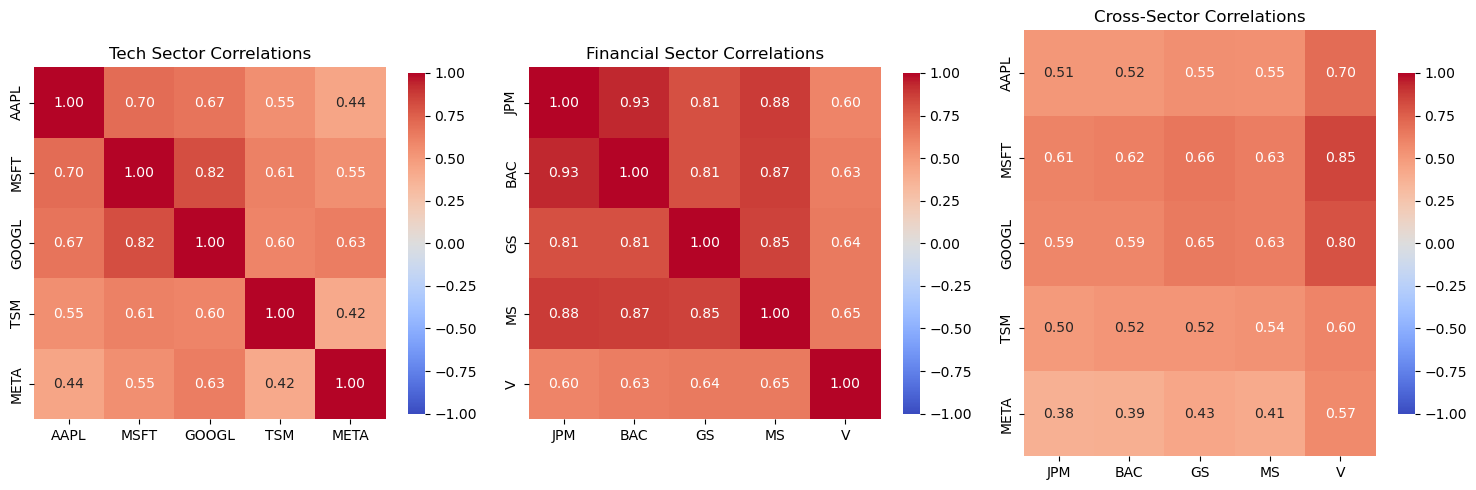

Average within tech correlation: 0.5974
Average within financial correlation: 0.7667
Average cross-sector correlation: 0.5723

Single Factor Model Results:
Missing values in excess returns: 22
Infinite values in excess returns: 0
Rows before cleaning: 251, after cleaning: 249
AAPL: α = 0.000321, β = 1.2382
MSFT: α = 0.001272, β = 1.4484
GOOGL: α = 0.000462, β = 1.3635
TSM: α = 0.000276, β = 1.0608
META: α = -0.000623, β = 1.2753
JPM: α = 0.000002, β = 0.9960
BAC: α = -0.000290, β = 1.0922
GS: α = -0.001057, β = 1.1209
MS: α = -0.000602, β = 1.2490
V: α = 0.001124, β = 1.2605

Residual Correlation Analysis:
Average residual correlation within tech: 0.1533
Average residual correlation within financial: 0.3595
Average residual correlation across sectors: -0.0028


In [80]:
# Expected returns (mean of excess returns)
mu = excess_returns.mean() * 252  # Annualized
# Covariance matrix
cov_matrix = excess_returns.cov() * 252  # Annualized

# S&P 500 stats
sp500_mu = mu['^GSPC']
sp500_sigma = np.sqrt(cov_matrix.loc['^GSPC', '^GSPC'])
print(f"\nS&P 500 Stats:")
print(f"Expected excess return (μ): {sp500_mu:.4f}")
print(f"Volatility (σ): {sp500_sigma:.4f}")

# Get sector covariance matrices
tech_cov = cov_matrix.loc[tech_stocks, tech_stocks]
financial_cov = cov_matrix.loc[financial_stocks, financial_stocks]

# (b) Examine covariance matrices
# Display the covariance matrices
print("\nTech Sector Covariance Matrix:")
print(tech_cov.round(4))

print("\nFinancial Sector Covariance Matrix:")
print(financial_cov.round(4))

print(f"\nCondition number of full covariance matrix: {np.linalg.cond(cov_matrix.iloc[:-1, :-1]):.2f}")
print(f"Condition number of tech sector: {np.linalg.cond(tech_cov):.2f}")
print(f"Condition number of financial sector: {np.linalg.cond(financial_cov):.2f}")

# Calculate correlation matrices
corr_matrix = excess_returns.corr()
tech_corr = corr_matrix.loc[tech_stocks, tech_stocks]
financial_corr = corr_matrix.loc[financial_stocks, financial_stocks]
cross_sector_corr = corr_matrix.loc[tech_stocks, financial_stocks]

print("\nCorrelation Analysis:")
# Display correlation matrices
print("\nTech Sector Correlation Matrix:")
print(tech_corr.round(4))
print("\nFinancial Sector Correlation Matrix:")
print(financial_corr.round(4))
print("\nCross-Sector Correlation Matrix:")
print(cross_sector_corr.round(4))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.heatmap(tech_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Tech Sector Correlations')

plt.subplot(1, 3, 2)
sns.heatmap(financial_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Financial Sector Correlations')

plt.subplot(1, 3, 3)
sns.heatmap(cross_sector_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Cross-Sector Correlations')

plt.tight_layout()
plt.show()

# Remove diagonal (self-correlations) from averages
tech_corr_no_diag = tech_corr.values.copy()
np.fill_diagonal(tech_corr_no_diag, np.nan)
financial_corr_no_diag = financial_corr.values.copy()
np.fill_diagonal(financial_corr_no_diag, np.nan)

print(f"Average within tech correlation: {np.nanmean(tech_corr_no_diag):.4f}")
print(f"Average within financial correlation: {np.nanmean(financial_corr_no_diag):.4f}")
print(f"Average cross-sector correlation: {cross_sector_corr.values.mean():.4f}")

# (c) Compute single factor model using S&P500
print("\nSingle Factor Model Results:")

# First, check for missing values in the data
print(f"Missing values in excess returns: {excess_returns.isna().sum().sum()}")
print(f"Infinite values in excess returns: {np.isinf(excess_returns).sum().sum()}")
# Clean the data by removing rows with NaN or inf values
clean_excess_returns = excess_returns.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Rows before cleaning: {len(excess_returns)}, after cleaning: {len(clean_excess_returns)}")

# Now run the regressions with clean data
betas = {}
alphas = {}
residuals = pd.DataFrame(index=clean_excess_returns.index)

for stock in stocks:
    # Regression against S&P500
    X = clean_excess_returns['^GSPC']
    y = clean_excess_returns[stock]
    
    # Calculate beta and alpha using linear regression:
    # We want to examine:
    #   r_k = alpha_k + beta_k * r_S&P + eps_k
    # Input:
    #   y - stock return (r_k)
    #   x - S&P return
    #   x_with_const - adds a column of 1's to solve for the intercept term alpha_k
    # Outputs:  
    #   model.params[0] - the alpha_k term above
    #   model.params[1] - beta_k term
    #   model.resid - residual eps_k term
    X_with_const = sm.add_constant(X)
    # Use OLS for LS problem:
    # https://www.geeksforgeeks.org/ordinary-least-squares-ols-using-statsmodels/
    model = sm.OLS(y, X_with_const).fit()
    
    beta = model.params[1]
    alpha = model.params[0]
    
    betas[stock] = beta
    alphas[stock] = alpha
    
    # Calculate residuals
    residuals[stock] = model.resid
    
    print(f"{stock}: α = {alpha:.6f}, β = {beta:.4f}")

# Correlation matrix of residuals
residual_corr = residuals.corr()
print("\nResidual Correlation Analysis:")
tech_residual_corr = residual_corr.loc[tech_stocks, tech_stocks]
financial_residual_corr = residual_corr.loc[financial_stocks, financial_stocks]
cross_sector_residual_corr = residual_corr.loc[tech_stocks, financial_stocks]

# Remove diagonal elements for accurate average calculation
tech_res_corr_no_diag = tech_residual_corr.values.copy()
np.fill_diagonal(tech_res_corr_no_diag, np.nan)
financial_res_corr_no_diag = financial_residual_corr.values.copy()
np.fill_diagonal(financial_res_corr_no_diag, np.nan)

print(f"Average residual correlation within tech: {np.nanmean(tech_res_corr_no_diag):.4f}")
print(f"Average residual correlation within financial: {np.nanmean(financial_res_corr_no_diag):.4f}")
print(f"Average residual correlation across sectors: {cross_sector_residual_corr.values.mean():.4f}")


# Comments on (a) (b) (c):
(A):
 - The S&P had a negative excess return during this time frame from calculating 
 mu = -0.0495, and volatility = 0.1701.

(B):
 - The covariance matrices within each sector make sense because of course they would be positively correlated with one another. 
 - The condition numbers provide information about the numerical stability of the system. The tech sector is relatively well-conditioned, with greater values of condition numbers implying more and more ill-conditioned. More ill-conditioned suggests greater interdependence according to a Google search. According to wikipedia an ill-conditioned problem is one where a small change in the inputs has a large change in the outputs, so in this case more independence among stocks in the portfolio because we examine the condition numbers of correlation matrices?
 - Looking at the average correlation within each sector (combined, tech, or financial) we see the lowest number being within the combined group. Thus the correlations are stronger within one sector which makes sense.
 
(C): 
 - A 'diagonal model' assumes the residuals across different stocks are uncorrelated (residual correlation matrix should be nearly diagonal). In looking at the values of the average residual correlation within the 3 groups we see that the single factor model is only really reasonable for the cross-sector model because the average residual correlation across sectors is essentially zero therefore meaning the stocks are uncorrelated. For the other two sectors this model is not appropriate since their residual correlation matrices are less diagonal i.e. average correlation is greater than zero.

In [81]:
# (d) Compute MVP, MP, and efficient frontier

# Only use stock returns (excluding S&P500)
stock_excess_returns = excess_returns.drop('^GSPC', axis=1)
stock_cov = cov_matrix.loc[stocks, stocks]
stock_mu = mu[stocks]

# Define functions for portfolio optimization
def portfolio_stats(weights, returns, cov):
    """Calculate portfolio statistics (return, volatility, Sharpe ratio)"""
    portfolio_return = np.sum(returns * weights)
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    return portfolio_return, portfolio_vol

def neg_sharpe_ratio(weights, returns, cov, risk_free_rate=0):
    """Calculate negative Sharpe ratio (for minimization)"""
    p_return, p_vol = portfolio_stats(weights, returns, cov)
    return -(p_return - risk_free_rate) / p_vol

def min_variance(returns, cov, allow_short=True):
    """Find minimum variance portfolio"""
    n = len(returns)
    args = (returns, cov)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # Set weight bounds for short selling or not
    if allow_short:
        bounds = tuple((-1, 1) for _ in range(n))  # Allow short selling
    else:
        bounds = tuple((0, 1) for _ in range(n))   # No short selling

    # Call the SciPy optimizer:
    #   portfolio_stats(weights, returns, cov)[1] - returns portfolio volatility
    #   np.ones(n) / n - starts optimizer with equally weighted portfolio
    #   constraints - ensures weights sum to 1
    result = sco.minimize(lambda weights, returns, cov: portfolio_stats(weights, returns, cov)[1],
                         np.ones(n) / n, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result['x']

def max_sharpe(returns, cov, risk_free_rate=0, max_position=0.3):
    """Find maximum Sharpe ratio portfolio with position limits"""
    n = len(returns)
    args = (returns, cov, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # Tighter bounds to prevent extreme positions
    #   max_position - limits investment into any single asset to +/- 30% (avoid over leverage)
    bounds = tuple((-max_position, max_position) for _ in range(n))
    
    # Call the SciPy optimizer:
    #   *Use the negative of the sharp ratio since minimize requires a minimum function
    
    result = sco.minimize(neg_sharpe_ratio, np.ones(n) / n, args=args, method='SLSQP', 
                         bounds=bounds, constraints=constraints)
    return result['x']

# Calculate MVP and MP (allowing short selling)
mvp_weights = min_variance(stock_mu, stock_cov, allow_short=True)
mp_weights = max_sharpe(stock_mu, stock_cov, 0, 0.3)


# MVP and MP return/volatility
mvp_return, mvp_vol = portfolio_stats(mvp_weights, stock_mu, stock_cov)
mp_return, mp_vol = portfolio_stats(mp_weights, stock_mu, stock_cov)

print("\nPortfolio Optimization Results:")
print(f"MVP - Expected Return: {mvp_return:.4f}, Volatility: {mvp_vol:.4f}")
print(f"MP - Expected Return: {mp_return:.4f}, Volatility: {mp_vol:.4f}")

# Calculate CML slope (Sharpe ratio of MP)
cml_slope = mp_return / mp_vol

# Calculate efficient frontier
target_returns = np.linspace(mvp_return, max(stock_mu) + 0.01, 50)
efficient_vols = []

for target in target_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(stock_mu * x) - target}
    )
    bounds = tuple((-1, 1) for _ in range(len(stock_mu)))  # Allow short selling
    
    result = sco.minimize(lambda x: np.sqrt(np.dot(x.T, np.dot(stock_cov, x))),
                         np.ones(len(stock_mu)) / len(stock_mu), method='SLSQP', 
                         bounds=bounds, constraints=constraints)
    
    if result['success']:
        efficient_vols.append(np.sqrt(np.dot(result['x'].T, np.dot(stock_cov, result['x']))))
    else:
        efficient_vols.append(np.nan)

# (e) Check for short-selling in MP portfolio
print("\nConstrained MP Weights:")
for stock, weight in zip(stocks, mp_weights):
    print(f"{stock}: {weight:.4f}" + (" (Short)" if weight < 0 else ""))

# Check if MP portfolio is "close" to S&P500
print(f"\nMP vs S&P500:")
print(f"MP Expected Return: {mp_return:.4f} vs S&P500: {sp500_mu:.4f}")
print(f"MP Volatility: {mp_vol:.4f} vs S&P500: {sp500_sigma:.4f}")
print(f"MP Sharpe Ratio: {mp_return/mp_vol:.4f} vs S&P500: {sp500_mu/sp500_sigma:.4f}")

# (f) Compute beta for each stock relative to the MP
# Recalculate MP returns and betas
mp_returns = np.zeros(len(clean_excess_returns))
for i, stock in enumerate(stocks):
    mp_returns += mp_weights[i] * clean_excess_returns[stock]

mp_returns = pd.Series(mp_returns, index=clean_excess_returns.index)

print("\nBetas relative to MP:")
mp_betas = {}
for stock in stocks:
    y = clean_excess_returns[stock]
    X = mp_returns
    
    # Check for valid data
    if X.var() > 0:  # Don't divide by zero
        # Calculate beta using covariance formula
        beta = np.cov(y, X)[0, 1] / np.var(X)
        mp_betas[stock] = beta
        print(f"{stock}: β = {beta:.4f}")
    else:
        print(f"{stock}: β calculation failed - zero variance in MP returns")


Portfolio Optimization Results:
MVP - Expected Return: 0.0294, Volatility: 0.1898
MP - Expected Return: 0.3658, Volatility: 0.2644

Constrained MP Weights:
AAPL: 0.3000
MSFT: 0.3000
GOOGL: 0.3000
TSM: 0.3000
META: -0.3000 (Short)
JPM: 0.3000
BAC: 0.1000
GS: -0.3000 (Short)
MS: -0.3000 (Short)
V: 0.3000

MP vs S&P500:
MP Expected Return: 0.3658 vs S&P500: -0.0495
MP Volatility: 0.2644 vs S&P500: 0.1701
MP Sharpe Ratio: 1.3835 vs S&P500: -0.2913

Betas relative to MP:
AAPL: β = 0.8521
MSFT: β = 0.8887
GOOGL: β = 0.8201
TSM: β = 0.7402
META: β = 0.3790
JPM: β = 0.4576
BAC: β = 0.5201
GS: β = 0.4540
MS: β = 0.5202
V: β = 0.7679


# Comments on (e) (f):
(e): 
 - Looking at the constrained MP weights, there is roughly 1/3rd short selling amongst all stocks. Of these stocks, they are set to the maximum constraint, which is -30%. 
 - The optimizer is taking maximum allowed positions suggesting the optimizer would take more extreme positions, but this could result in extremely leveraged positions which are risky!
 - Comparing to the S&P: the expected return is significantly better than the S&P although I do not know how practical these results really are... So we can just beat the market like this? The tradeoff is that the MP has a larger volatility and much higher Sharpe ratio which suggests it is not practically "close" in terms of the risk-return profile.

(F):
 - Analyzing the beta's relative to the MP, the stocks with the larger betas (tech stocks) imply that they move more closely with the MP than the financial stocks.

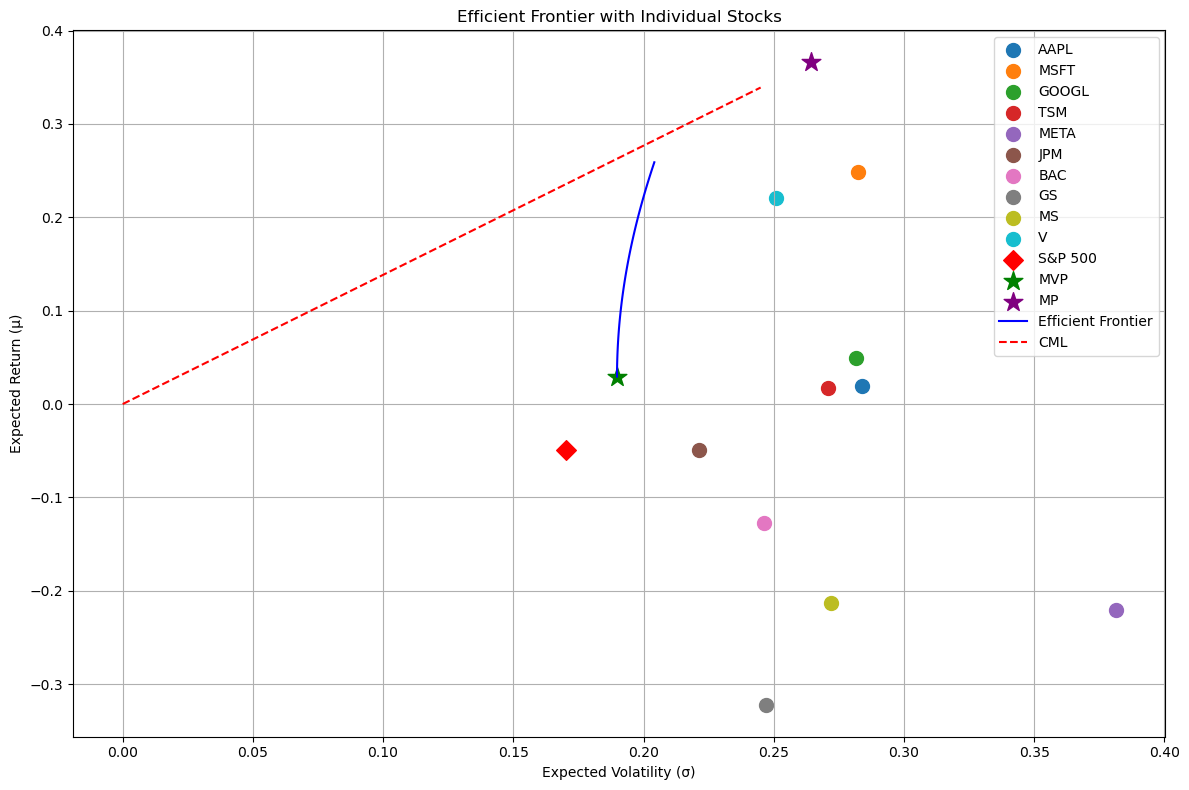

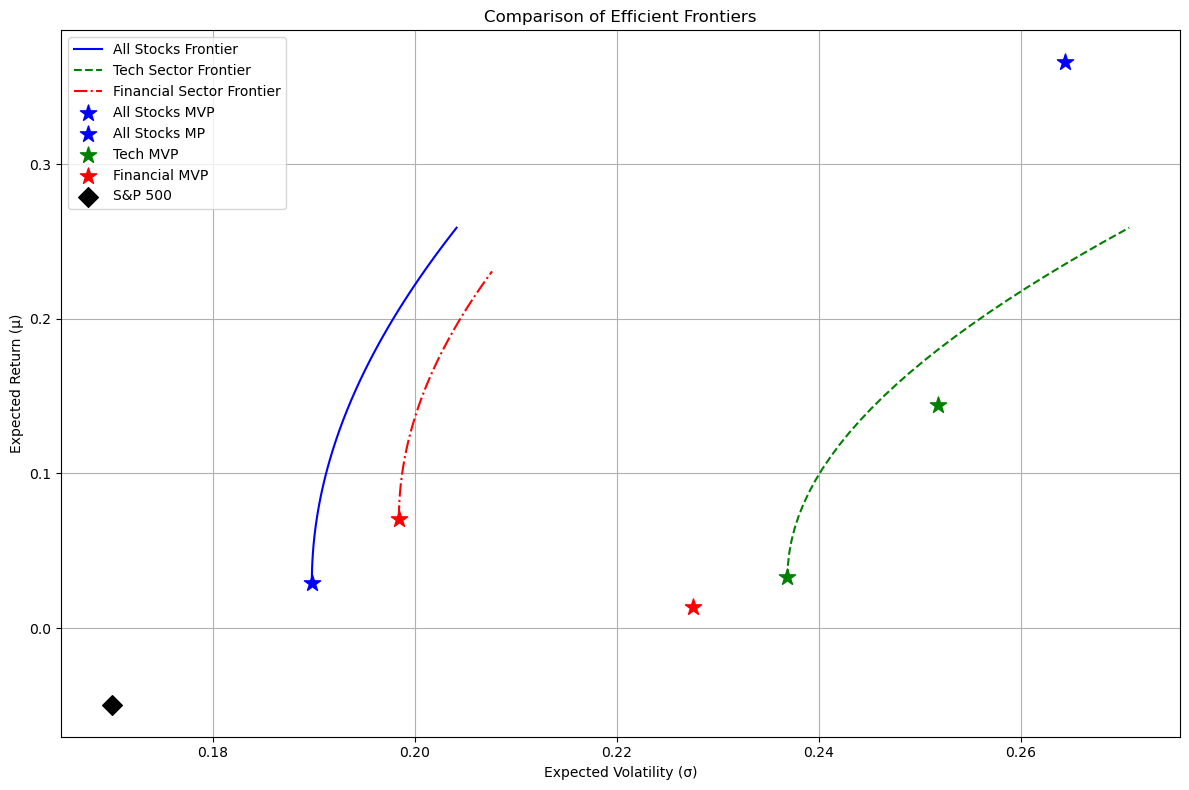

In [82]:
# Create plots to visualize the results
plt.figure(figsize=(12, 8))

# Plot individual stocks
for i, stock in enumerate(stocks):
    plt.scatter(np.sqrt(stock_cov.iloc[i, i]), stock_mu[i], marker='o', 
                label=stock, s=100)

# Plot S&P 500
plt.scatter(sp500_sigma, sp500_mu, marker='D', color='red', s=100, label='S&P 500')

# Plot MVP and MP
plt.scatter(mvp_vol, mvp_return, marker='*', color='green', s=200, label='MVP')
plt.scatter(mp_vol, mp_return, marker='*', color='purple', s=200, label='MP')

# Plot efficient frontier
plt.plot(efficient_vols, target_returns, 'b-', label='Efficient Frontier')

# Plot CML
x_range = np.linspace(0, max(efficient_vols)*1.2, 100)
plt.plot(x_range, cml_slope * x_range, 'r--', label='CML')

plt.title('Efficient Frontier with Individual Stocks')
plt.xlabel('Expected Volatility (σ)')
plt.ylabel('Expected Return (μ)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot sector-specific efficient frontiers
# Tech sector
tech_mu = mu[tech_stocks]
tech_mvp_weights = min_variance(tech_mu, tech_cov)
tech_mp_weights = max_sharpe(tech_mu, tech_cov)
tech_mvp_return, tech_mvp_vol = portfolio_stats(tech_mvp_weights, tech_mu, tech_cov)
tech_mp_return, tech_mp_vol = portfolio_stats(tech_mp_weights, tech_mu, tech_cov)

# Financial sector
fin_mu = mu[financial_stocks]
fin_mvp_weights = min_variance(fin_mu, financial_cov)
fin_mp_weights = max_sharpe(fin_mu, financial_cov)
fin_mvp_return, fin_mvp_vol = portfolio_stats(fin_mvp_weights, fin_mu, financial_cov)
fin_mp_return, fin_mp_vol = portfolio_stats(fin_mp_weights, fin_mu, financial_cov)

# Plot comparison of efficient frontiers
plt.figure(figsize=(12, 8))

# Plot full portfolio efficient frontier
plt.plot(efficient_vols, target_returns, 'b-', label='All Stocks Frontier')

# Plot tech sector efficient frontier
tech_returns = np.linspace(tech_mvp_return, max(tech_mu) + 0.01, 30)
tech_vols = []
for target in tech_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(tech_mu * x) - target}
    )
    bounds = tuple((-1, 1) for _ in range(len(tech_mu)))
    result = sco.minimize(lambda x: np.sqrt(np.dot(x.T, np.dot(tech_cov, x))),
                          np.ones(len(tech_mu)) / len(tech_mu), method='SLSQP',
                          bounds=bounds, constraints=constraints)
    if result['success']:
        tech_vols.append(np.sqrt(np.dot(result['x'].T, np.dot(tech_cov, result['x']))))
    else:
        tech_vols.append(np.nan)

# Plot financial sector efficient frontier 
fin_returns = np.linspace(fin_mvp_return, max(fin_mu) + 0.01, 30)
fin_vols = []
for target in fin_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(fin_mu * x) - target}
    )
    bounds = tuple((-1, 1) for _ in range(len(fin_mu)))
    result = sco.minimize(lambda x: np.sqrt(np.dot(x.T, np.dot(financial_cov, x))),
                          np.ones(len(fin_mu)) / len(fin_mu), method='SLSQP',
                          bounds=bounds, constraints=constraints)
    if result['success']:
        fin_vols.append(np.sqrt(np.dot(result['x'].T, np.dot(financial_cov, result['x']))))
    else:
        fin_vols.append(np.nan)

plt.plot(tech_vols, tech_returns, 'g--', label='Tech Sector Frontier')
plt.plot(fin_vols, fin_returns, 'r-.', label='Financial Sector Frontier')

plt.scatter(mvp_vol, mvp_return, marker='*', color='blue', s=150, label='All Stocks MVP')
plt.scatter(mp_vol, mp_return, marker='*', color='blue', s=150, label='All Stocks MP')
plt.scatter(tech_mvp_vol, tech_mvp_return, marker='*', color='green', s=150, label='Tech MVP')
plt.scatter(tech_mp_vol, tech_mp_return, marker='*', color='green', s=150)
plt.scatter(fin_mvp_vol, fin_mvp_return, marker='*', color='red', s=150, label='Financial MVP')
plt.scatter(fin_mp_vol, fin_mp_return, marker='*', color='red', s=150)
plt.scatter(sp500_sigma, sp500_mu, marker='D', color='black', s=100, label='S&P 500')

plt.title('Comparison of Efficient Frontiers')
plt.xlabel('Expected Volatility (σ)')
plt.ylabel('Expected Return (μ)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Section 2 - Examine the Security Market Line 

Number of trading days in January 2018: 21
Number of trading days in February 2018: 19
AAPL January beta: 1.1480
MSFT January beta: 1.3813
GOOGL January beta: 1.0442
TSM January beta: 1.4876
META January beta: 0.7534
JPM January beta: 0.5729
BAC January beta: 0.4820
GS January beta: -0.0482
MS January beta: 0.8225
V January beta: 1.0372
AAPL February average return: 0.003666
MSFT February average return: -0.000233
GOOGL February average return: -0.003349
TSM February average return: -0.002157
META February average return: -0.002235
JPM February average return: 0.000092
BAC February average return: 0.000345
GS February average return: -0.000624
MS February average return: -0.000275
V February average return: -0.000279
S&P 500 February average return: -0.002010


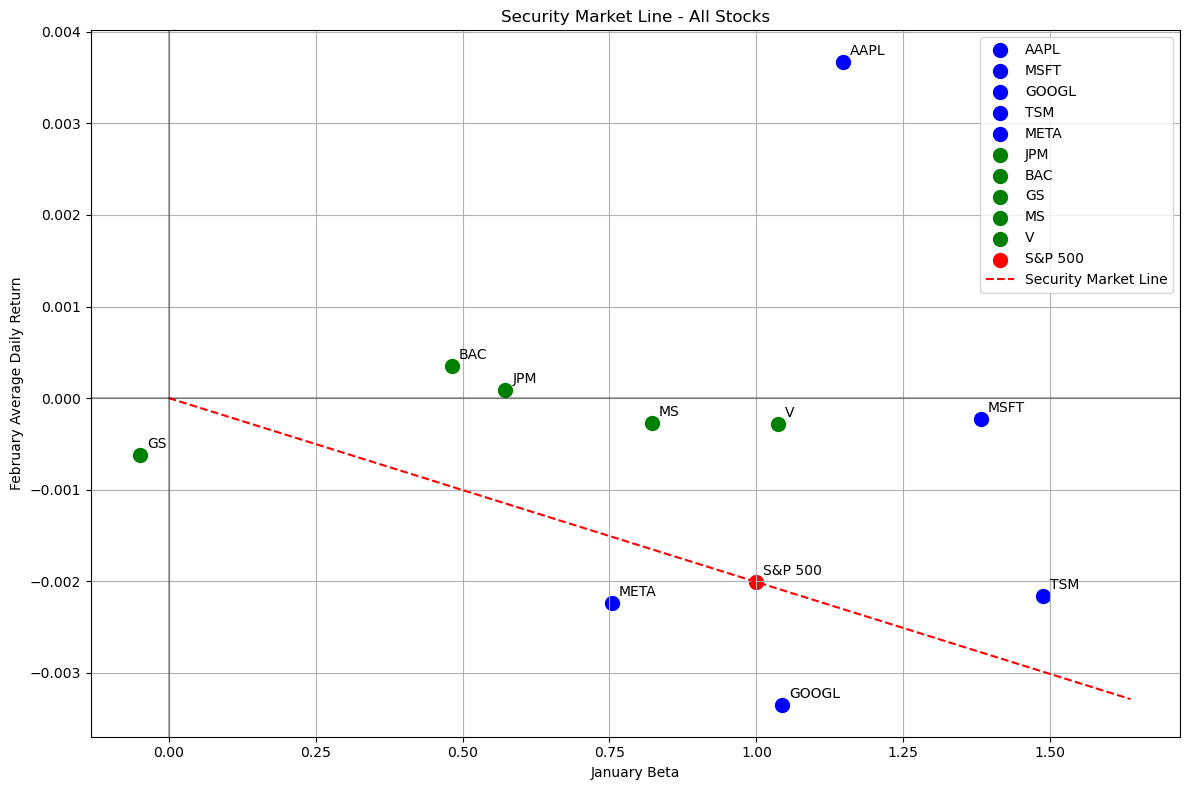

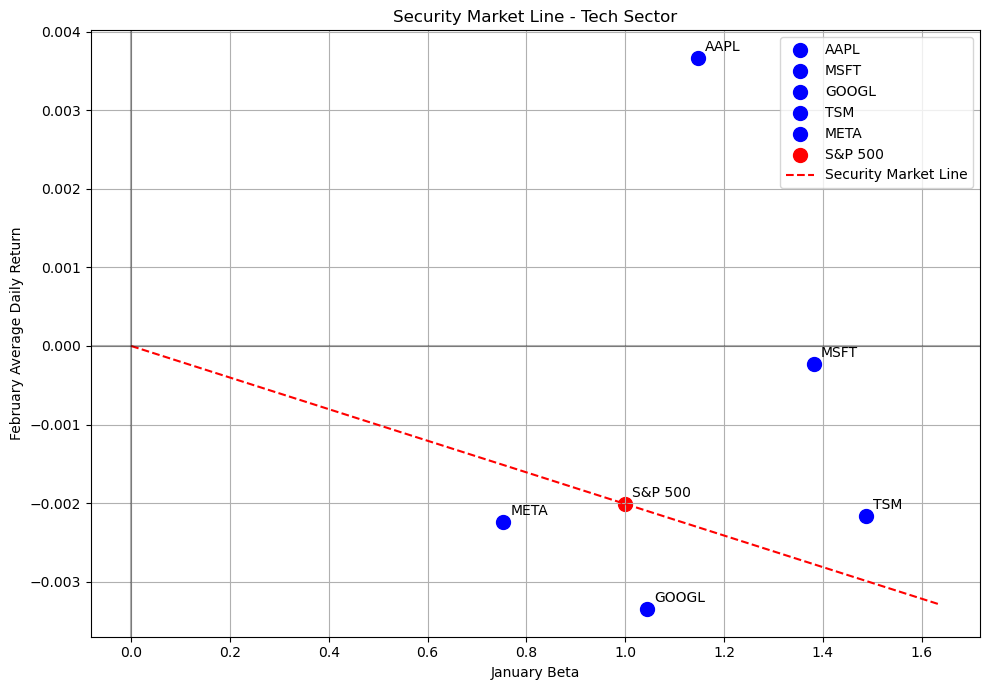

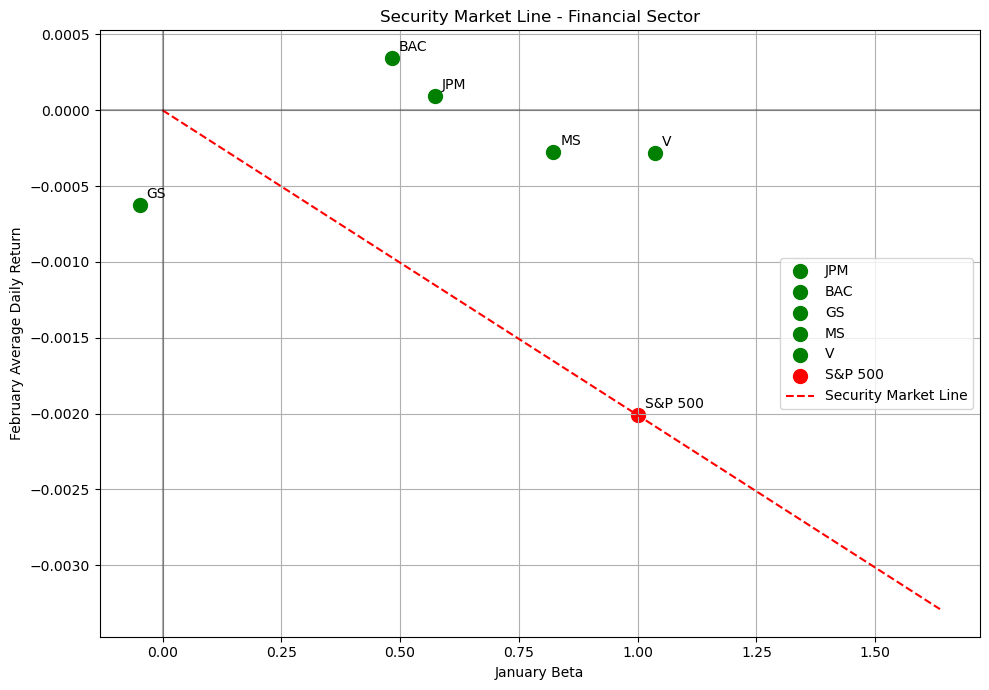

In [83]:
# Separate data by month
jan_mask = (clean_excess_returns.index.month == 1) & (clean_excess_returns.index.year == 2018)
feb_mask = (clean_excess_returns.index.month == 2) & (clean_excess_returns.index.year == 2018)

jan_returns = clean_excess_returns[jan_mask]
feb_returns = clean_excess_returns[feb_mask]

# Calculate January betas and expected returns
jan_betas = {}
jan_expected_returns = {}

# Calculate S&P 500 expected return for January
jan_sp500_return = jan_returns['^GSPC'].mean()

print(f"Number of trading days in January 2018: {len(jan_returns)}")
print(f"Number of trading days in February 2018: {len(feb_returns)}")

# Calculate January betas for each stock
for stock in stocks:
    X = jan_returns['^GSPC']
    y = jan_returns[stock]
    
    # Calculate beta using the theorem in Port_03_CAPM pg. 5
    beta = np.cov(y, X)[0, 1] / np.var(X)
    jan_betas[stock] = beta
    jan_expected_returns[stock] = jan_returns[stock].mean()
    
    print(f"{stock} January beta: {beta:.4f}")

# Calculate February average returns
feb_expected_returns = {}
feb_sp500_return = feb_returns['^GSPC'].mean()

for stock in stocks:
    feb_expected_returns[stock] = feb_returns[stock].mean()
    print(f"{stock} February average return: {feb_expected_returns[stock]:.6f}")

print(f"S&P 500 February average return: {feb_sp500_return:.6f}")

# Plot the Security Market Line for all stocks
plt.figure(figsize=(12, 8))

# Plot the stocks
for stock in stocks:
    if stock in tech_stocks:
        plt.scatter(jan_betas[stock], 
                    feb_expected_returns[stock], 
                    color='blue', 
                    label=stock if 'Tech' not in plt.gca().get_legend_handles_labels()[1] else "", s=100)
    else:  # Financial stocks
        plt.scatter(jan_betas[stock], 
                    feb_expected_returns[stock], 
                    color='green', 
                    label=stock if 'Financial' not in plt.gca().get_legend_handles_labels()[1] else "", s=100)

# Add labels
for stock in stocks:
    plt.annotate(stock, (jan_betas[stock], feb_expected_returns[stock]), 
                xytext=(5, 5), textcoords='offset points')

# Plot S&P 500
plt.scatter(1, feb_sp500_return, color='red', s=100, label='S&P 500')
plt.annotate('S&P 500', (1, feb_sp500_return), xytext=(5, 5), textcoords='offset points')

# Plot the SML line
x_range = np.linspace(0, max(jan_betas.values()) * 1.1, 100)
sml_y = feb_sp500_return * x_range  # SML passes through (0,0) and (1, S&P500 return)
plt.plot(x_range, sml_y, 'r--', label='Security Market Line')

plt.xlabel('January Beta')
plt.ylabel('February Average Daily Return')
plt.title('Security Market Line - All Stocks')
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Create separate plots for the tech and finance sector:
# Tech Sector
plt.figure(figsize=(10, 7))
for stock in tech_stocks:
    plt.scatter(jan_betas[stock], feb_expected_returns[stock], color='blue', label=stock, s=100)
    plt.annotate(stock, (jan_betas[stock], feb_expected_returns[stock]), 
                xytext=(5, 5), textcoords='offset points')
    
plt.scatter(1, feb_sp500_return, color='red', s=100, label='S&P 500')
plt.annotate('S&P 500', (1, feb_sp500_return), xytext=(5, 5), textcoords='offset points')
plt.plot(x_range, sml_y, 'r--', label='Security Market Line')
plt.xlabel('January Beta')
plt.ylabel('February Average Daily Return')
plt.title('Security Market Line - Tech Sector')
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Financial Sector
plt.figure(figsize=(10, 7))
for stock in financial_stocks:
    plt.scatter(jan_betas[stock], feb_expected_returns[stock], color='green', label=stock, s=100)
    plt.annotate(stock, (jan_betas[stock], feb_expected_returns[stock]), 
                xytext=(5, 5), textcoords='offset points')
    
plt.scatter(1, feb_sp500_return, color='red', s=100, label='S&P 500')
plt.annotate('S&P 500', (1, feb_sp500_return), xytext=(5, 5), textcoords='offset points')
plt.plot(x_range, sml_y, 'r--', label='Security Market Line')
plt.xlabel('January Beta')
plt.ylabel('February Average Daily Return')
plt.title('Security Market Line - Financial Sector')
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Comments on Section 2
In examining the plots we can essentially analyze which stocks outperformed or underperformed relative to the 'market' (S&P). Sometimes the average daily return is in the negative but relative to the SML, investing in these stocks would have yielded better performance than investing in the market.

These tests demonstrates the predicted February daily return for a stock given its January Beta.

------------
## Section 3 - Self-Financing Adaptive Portfolio Strategy

Month 1: 21 trading days, last day: 2018-01-31
Month 2: 19 trading days, last day: 2018-02-28
Month 3: 21 trading days, last day: 2018-03-29
Month 4: 21 trading days, last day: 2018-04-30
Month 5: 22 trading days, last day: 2018-05-31
Month 6: 21 trading days, last day: 2018-06-29
Month 7: 21 trading days, last day: 2018-07-31
Month 8: 23 trading days, last day: 2018-08-31
Month 9: 19 trading days, last day: 2018-09-28
Month 10: 22 trading days, last day: 2018-10-31
Month 11: 20 trading days, last day: 2018-11-30
Month 12: 19 trading days, last day: 2018-12-31

Initial Portfolio Weights (January):

All_Stocks MP:
 AAPL: -0.3000 (Short)
 MSFT: -0.0590 (Short)
 GOOGL: 0.3000
 TSM: -0.0165 (Short)
 META: 0.0989
 JPM: 0.3000
 BAC: 0.3000
 GS: -0.1113 (Short)
 MS: 0.1879
 V: 0.3000

Tech MP:
 AAPL: -0.0969 (Short)
 MSFT: 0.3000
 GOOGL: 0.3000
 TSM: 0.3000
 META: 0.1969

Financial MP:
 JPM: 0.3000
 BAC: 0.2962
 GS: 0.0363
 MS: 0.0676
 V: 0.3000

Final portfolio values (end of December):
All_

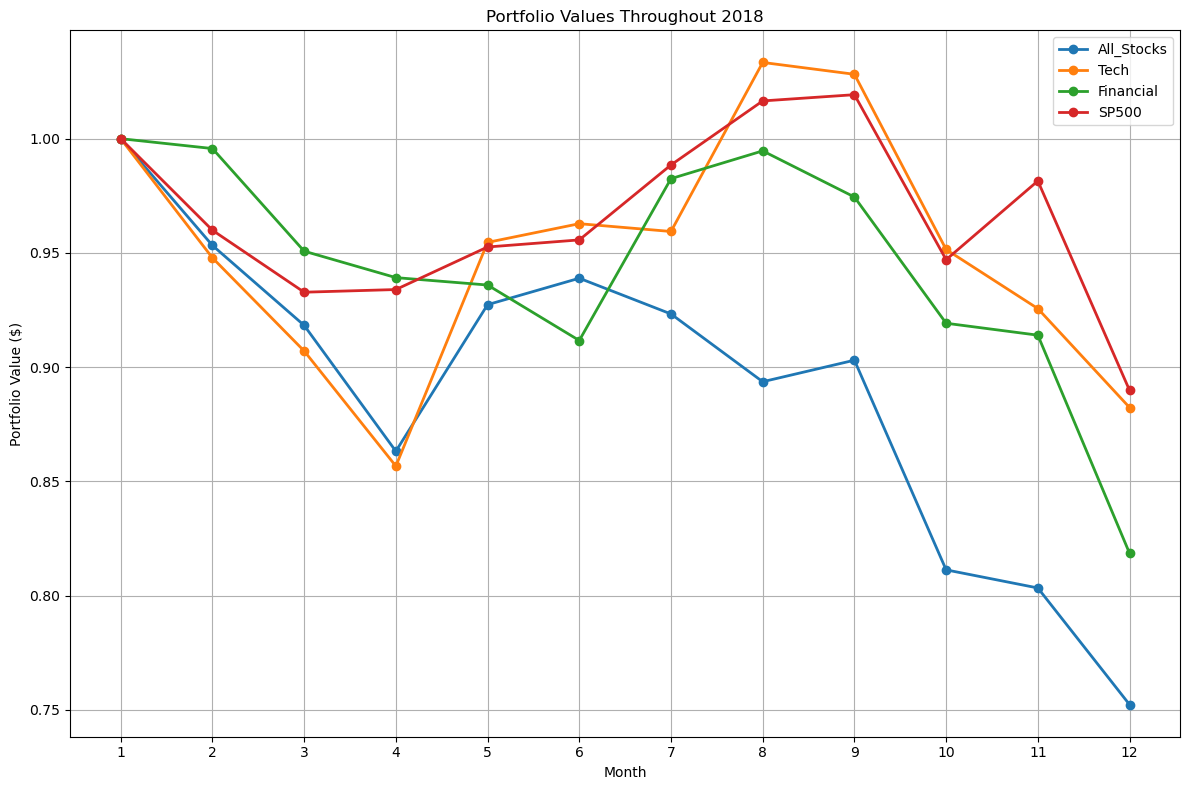

All_Stocks maintained a positive value throughout. Minimum: $0.7522
Tech maintained a positive value throughout. Minimum: $0.8567
Financial maintained a positive value throughout. Minimum: $0.8185
SP500 maintained a positive value throughout. Minimum: $0.8898


In [84]:
# Function to find last trading day of each month
def get_last_trading_day(returns_df, year, month):
    month_data = returns_df[(returns_df.index.year == year) & (returns_df.index.month == month)]
    if len(month_data) > 0:
        return month_data.index[-1]
    return None

# Function to calculate MP for a given subset of stocks and month
def calculate_monthly_mp(month_returns, stock_list, max_position=0.3):
    if len(month_returns) == 0:
        return None
    
    # Calculate monthly expected returns and covariance
    month_mu = month_returns[stock_list].mean() * 21  # Approximate trading days in month (no weekends)
    month_cov = month_returns[stock_list].cov() * 21
    
    # Find MP
    n = len(stock_list)
    args = (month_mu, month_cov, 0)  # 0 is risk-free rate
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    # Max portfolio weights for each stock in the stock list
    bounds = tuple((-max_position, max_position) for _ in range(n))
    
    initial_weights = np.ones(n) / n
    result = sco.minimize(neg_sharpe_ratio, initial_weights, args=args, 
                         method='SLSQP', bounds=bounds, constraints=constraints)
    
    if result['success']:
        return dict(zip(stock_list, result['x']))
    else:
        print(f"Optimization failed for month {month}")
        return dict(zip(stock_list, initial_weights))
    

# Extract returns by month for 2018
months = range(1, 13)  # January through December
last_trading_days = {}
monthly_returns = {}

for month in months:
    # Take the year 2018 and all months from start to end of year
    month_mask = (clean_excess_returns.index.year == 2018) & (clean_excess_returns.index.month == month)
    monthly_returns[month] = clean_excess_returns[month_mask]   # Returns for the given month
    if len(monthly_returns[month]) > 0:
        last_trading_days[month] = monthly_returns[month].index[-1] # Last trading day return
        print(f"Month {month}: {len(monthly_returns[month])} trading days, last day: {last_trading_days[month].date()}")

# Initialize portfolios
portfolio_values = {
    'All_Stocks': [1.0],
    'Tech': [1.0],
    'Financial': [1.0],
    'SP500': [1.0]
}

current_weights = {
    'All_Stocks': None,
    'Tech': None,
    'Financial': None
}

# Calculate January MPs to start
jan_returns = monthly_returns[1]
current_weights['All_Stocks'] = calculate_monthly_mp(jan_returns, stocks)
current_weights['Tech'] = calculate_monthly_mp(jan_returns, tech_stocks)
current_weights['Financial'] = calculate_monthly_mp(jan_returns, financial_stocks)

# Display initial weights
print("\nInitial Portfolio Weights (January):")
for portfolio, weights in current_weights.items():
    print(f"\n{portfolio} MP:")
    for stock, weight in weights.items():
        print(f" {stock}: {weight:.4f}" + (" (Short)" if weight < 0 else ""))

# Simulate monthly portfolio performance
for month in range(2, 13):
    if month not in monthly_returns or len(monthly_returns[month]) == 0:
        print(f"No data for month {month}")
        continue

    # Get the returns for this month:
    month_data = monthly_returns[month]

    # Calculate cumulative return for each stock over the month
    cumulative_month_returns = {}
    for stock in stocks + ["^GSPC"]:
        # Calculate compound return over the month
        daily_rets = month_data[stock] + 1  # Convert excess returns to gross returns
        cumulative_month_returns[stock] = np.prod(daily_rets) - 1

    # Update portfolio values
    for portfolio, weights in current_weights.items():
        port_return = 0
        for stock, weight in weights.items():
            port_return += weight * cumulative_month_returns[stock]

        # Update the value of the portfolio
        current_value = portfolio_values[portfolio][-1]
        new_value = current_value * (1 + port_return)
        portfolio_values[portfolio].append(new_value)

        if new_value < 0:
            print(f"Warning: {portfolio} portfolio has a negative value in month {month}: ${new_value:.4f}")

    # Update the S&P500 benchmark
    sp500_value = portfolio_values['SP500'][-1]
    portfolio_values['SP500'].append(sp500_value * (1 + cumulative_month_returns['^GSPC']))

    ''' Recalculate MPs for the next month excluding December '''
    if month < 12:
        next_month = month + 1
        if next_month in monthly_returns and len(monthly_returns[next_month]) > 0:
            current_weights['All_Stocks'] = calculate_monthly_mp(month_data, stocks)
            current_weights['Tech'] = calculate_monthly_mp(month_data, tech_stocks)
            current_weights['Financial'] = calculate_monthly_mp(month_data, financial_stocks)

# Display the portfolio values at the end of the months
print("\nFinal portfolio values (end of December):")
for portfolio, values in portfolio_values.items():
    final_value = values[-1]
    returns = (final_value - 1) * 100
    print(f"{portfolio}: ${final_value:.4f} (Return: {returns:.2f}%)")

# Plot the portfolio values over time
plt.figure(figsize=(12,8))
months_list = list(range(1, len(portfolio_values['All_Stocks']) + 1))

for portfolio, values in portfolio_values.items():
    plt.plot(months_list, values, marker = 'o', linewidth=2, label=portfolio)

plt.title("Portfolio Values Throughout 2018")
plt.xlabel('Month')
plt.ylabel('Portfolio Value ($)')
plt.xticks(months_list)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Finally check for any negative portfolios
min_values = {}
for portfolio, values in portfolio_values.items():
    min_values[portfolio] = min(values)
    if min_values[portfolio] < 0:
        print(f"{portfolio} had a negative value during the year. Minimum: ${min_values[portfolio]:.4f}")
    else:
        print(f"{portfolio} maintained a positive value throughout. Minimum: ${min_values[portfolio]:.4f}")
        

# Section 3 Comments
Throughout the 2018 year this dynamic MP strategy could not outperform passively investing in the S&P. I attempted to change the maximum bounds acceptable by the MP (increased to 1 instead of 0.3) which led to even more dramatic losses. By increasing the acceptable bounds the variation in the portfolio value can change very dramatically.It appears that this year (2018) was challenging for the market so it would be especially difficult to beat expected returns during this year with this dynamic strategy.